# Feature Selection and Initial Modeling
### This file will explore which features to use, using the following techniques:
- Pearson Correlation Matrix
- Lasso Regression (it makes weak predictors 0)

### Then we will establish the baseline model:
- Multivariate Linear Regression

### Import and Setup

In [70]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score

# Load 10% training sample for experiments
train_sample_raw = pd.read_csv('train_sample_2.csv')
train_sample_raw.shape

(1086590, 49)

In [71]:
# Drop not needed columns
cols_to_drop = [
    'trips_ended', 'net_flow', 
    'station_id', 'station_name', 
    'date', 'datetime'
]

# Create cleaned dataset for analysis
train_sample_clean = train_sample_raw.drop(columns=cols_to_drop, errors='ignore')

In [72]:
# Ensure booleans are treated as numbers
bool_cols = train_sample_clean.select_dtypes(include=['bool']).columns
train_sample_clean[bool_cols] = train_sample_clean[bool_cols].astype(int)

In [73]:
print(f"Analysis Dimension: {train_sample_clean.drop(columns='trips_started', axis=1).shape[1]} features")
print(f"Shape: {train_sample_clean.shape}")
print(train_sample_clean.columns)

Analysis Dimension: 42 features
Shape: (1086590, 43)
Index(['hour', 'day_of_week', 'month', 'year', 'is_weekend', 'is_am_rush_hour',
       'is_pm_rush_hour', 'trips_started', 'temp_c', 'dew_point_c',
       'rel_humidity_pct', 'precip_mm', 'wind_speed_kmh', 'visibility_km',
       'pressure_kpa', 'latitude', 'longitude', 'capacity',
       'is_charging_station', 'bus', 'subway', 'streetcar', 'train',
       'public_transport_total', 'tourism', 'office', 'park', 'healthcare',
       'education', 'restaurants_bars', 'commercial', 'cluster_east_end',
       'cluster_scarborough', 'cluster_uptown', 'cluster_west_end',
       'dist_to_union_km', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
       'month_sin', 'month_cos', 'day_of_year'],
      dtype='object')


### Pearson Correlation Matrix

Top 10 Positively Correlated Features:
trips_started       1.000000
tourism             0.299576
restaurants_bars    0.295678
office              0.264245
park                0.260122
healthcare          0.248300
temp_c              0.246143
streetcar           0.244700
commercial          0.241370
hour                0.209645
Name: trips_started, dtype: float64

Top 10 Negatively Correlated Features:
cluster_scarborough   -0.109596
cluster_west_end      -0.132150
cluster_uptown        -0.137337
cluster_east_end      -0.139422
month_cos             -0.147104
month_sin             -0.161248
hour_cos              -0.193447
hour_sin              -0.219675
latitude              -0.225175
dist_to_union_km      -0.368562
Name: trips_started, dtype: float64
All Correlations:
trips_started             1.000000
tourism                   0.299576
restaurants_bars          0.295678
office                    0.264245
park                      0.260122
healthcare                0.248300
temp_c     

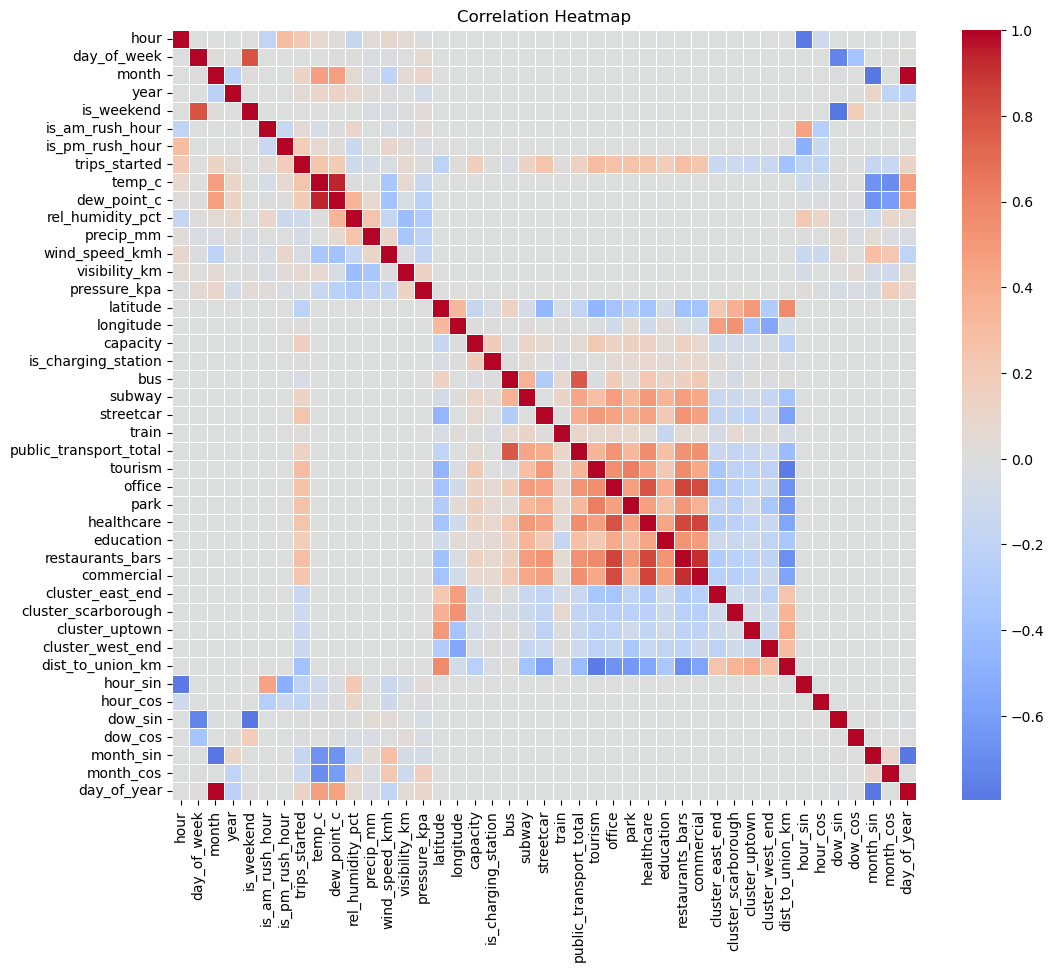

In [74]:
corr_matrix = train_sample_clean.corr()

# Show correlations with the target variable
target_corr = corr_matrix['trips_started'].sort_values(ascending=False)

print("Top 10 Positively Correlated Features:")
print(target_corr.head(10))
print("\nTop 10 Negatively Correlated Features:")
print(target_corr.tail(10))
print("All Correlations:")
print(target_corr)

# OPTIONAL: Plot Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

### Lasso Regression

In [75]:
# 1. Define the features to drop
new_cols_to_drop = [
    'hour', 
    'month', 
    'day_of_week', 
    'day_of_year', 
    'public_transport_total', 
    'dew_point_c', 
]

In [76]:
all_dropped_cols = cols_to_drop + new_cols_to_drop

# Load Validation Data
test_clean = pd.read_csv('test_2.csv').drop(columns=all_dropped_cols, errors='ignore')

In [77]:
# Prepare validation features and target for Lasso
X_test_lasso = test_clean.drop(columns='trips_started', axis=1)
y_test_lasso = test_clean['trips_started']

print(f"Test data shape: {test_clean.shape}")
print(X_test_lasso.info())

Test data shape: (1338746, 37)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338746 entries, 0 to 1338745
Data columns (total 36 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   year                 1338746 non-null  int64  
 1   is_weekend           1338746 non-null  bool   
 2   is_am_rush_hour      1338746 non-null  bool   
 3   is_pm_rush_hour      1338746 non-null  bool   
 4   temp_c               1338746 non-null  float64
 5   rel_humidity_pct     1338746 non-null  float64
 6   precip_mm            1338746 non-null  float64
 7   wind_speed_kmh       1338746 non-null  float64
 8   visibility_km        1338746 non-null  float64
 9   pressure_kpa         1338746 non-null  float64
 10  latitude             1338746 non-null  float64
 11  longitude            1338746 non-null  float64
 12  capacity             1338746 non-null  int64  
 13  is_charging_station  1338746 non-null  bool   
 14  bus                

In [78]:
# Prepare feature set for Lassso
train_sample_lasso = train_sample_clean.drop(columns=all_dropped_cols, errors='ignore')

In [79]:
# Prepare features and target for Lasso
X_train_sample_lasso = train_sample_lasso.drop(columns='trips_started')
y_train_sample_lasso = train_sample_lasso['trips_started']

# Scale features
scaler_lasso = StandardScaler()
X_train_sample_lasso_scaled = scaler_lasso.fit_transform(X_train_sample_lasso)
X_test_lasso_scaled = scaler_lasso.transform(X_test_lasso)

print(f"Train scaled shape: {X_train_sample_lasso_scaled.shape}")
print(f"Test scaled shape: {X_test_lasso_scaled.shape}")

Train scaled shape: (1086590, 36)
Test scaled shape: (1338746, 36)


In [80]:
# Cross validation to find best alpha for Lasso
lasso_cv = LassoCV(alphas=[0.000001, 0.00001, 0.0001, 0.001, 0.01], cv=5, random_state=42)
lasso_cv.fit(X_train_sample_lasso_scaled, y_train_sample_lasso)
lasso_alpha = lasso_cv.alpha_

print(f"Lasso Regression - Best Alpha: {lasso_alpha}")

Lasso Regression - Best Alpha: 1e-05


In [81]:
# Ignore results of LassoCV. There are too many observations for the given number of features.
alpha_0 = 0.0001
alpha_1 = 0.001
alpha_2 = 0.01

lasso_0 = Lasso(alpha=alpha_0, random_state=42)
lasso_0.fit(X_train_sample_lasso_scaled, y_train_sample_lasso)

lasso_1 = Lasso(alpha=alpha_1, random_state=42)
lasso_1.fit(X_train_sample_lasso_scaled, y_train_sample_lasso)

lasso_2 = Lasso(alpha=alpha_2, random_state=42)
lasso_2.fit(X_train_sample_lasso_scaled, y_train_sample_lasso)

,alpha,0.01
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,42
,selection,'cyclic'


In [82]:
import numpy as np

# Compare Performance
models = {
    f"Alpha {alpha_0}": lasso_0,
    f"Alpha {alpha_1}": lasso_1,
    f"Alpha {alpha_2}": lasso_2
}

feature_names = X_train_sample_lasso.columns

results = []

for name, model in models.items():
    # Predict on test set
    y_pred = model.predict(X_test_lasso_scaled)
    
    # Calculate Scores
    rmse = np.sqrt(mean_squared_error(y_test_lasso, y_pred))

    lasso_train_score = model.score(X_train_sample_lasso_scaled, y_train_sample_lasso)
    lasso_test_score = model.score(X_test_lasso_scaled, y_test_lasso)

    
    # Count Non-Zero Coefficients
    n_features = np.sum(model.coef_ != 0)
    
    results.append({
        'Model': name,
        'RMSE': rmse,
        'R^2 - Train': lasso_train_score,
        'R^2 - Test': lasso_test_score,
        'Features Kept': n_features,
        'Features Dropped': len(feature_names) - n_features
    })

print("\n--- Performance Trade-off ---")
print(pd.DataFrame(results))


--- Performance Trade-off ---
          Model      RMSE  R^2 - Train  R^2 - Test  Features Kept  \
0  Alpha 0.0001  0.498699     0.307899    0.312158             36   
1   Alpha 0.001  0.498810     0.307655    0.311851             34   
2    Alpha 0.01  0.501351     0.301482    0.304824             23   

   Features Dropped  
0                 0  
1                 2  
2                13  


In [83]:
# Coefficient comparison
coef_comparison = pd.DataFrame({'Feature': feature_names})

for name, model in models.items():
    coef_comparison[name] = model.coef_

# Sort by the magnitude of the smallest alpha (Linear Regression equivalent)
coef_comparison['Sort_Key'] = coef_comparison[f"Alpha {alpha_0}"].abs()
coef_comparison = coef_comparison.sort_values(by='Sort_Key', ascending=False).drop(columns='Sort_Key')

print(f"\n--- Coefficient Shrinkage (Top 20 Features) ---")
print(coef_comparison.head)

# OPTIONAL: View only the features that survived the most aggressive alpha
survivors = coef_comparison[coef_comparison[f"Alpha {alpha_2}"] != 0]
print(f"\n--- Survivors at Alpha {alpha_2} ---")
print(survivors['Feature'].tolist())


--- Coefficient Shrinkage (Top 20 Features) ---
<bound method NDFrame.head of                 Feature  Alpha 0.0001  Alpha 0.001  Alpha 0.01
30             hour_sin     -0.132298    -0.130662   -0.114990
29     dist_to_union_km     -0.119424    -0.126654   -0.138595
31             hour_cos     -0.087001    -0.086308   -0.080101
4                temp_c      0.086185     0.088750    0.108730
2       is_am_rush_hour      0.068605     0.067226    0.053194
12             capacity      0.052746     0.052291    0.043351
23     restaurants_bars      0.047258     0.033807    0.024410
25     cluster_east_end     -0.041153    -0.032863   -0.019080
34            month_sin     -0.037843    -0.035584   -0.015641
22            education      0.037723     0.036962    0.028530
10             latitude     -0.034706    -0.031316   -0.018453
28     cluster_west_end     -0.034084    -0.033838   -0.018242
3       is_pm_rush_hour      0.033925     0.033565    0.030028
0                  year      0.024670  

### Lasso Regression Results Analysis

Features to be used for Lasso, MLR, Random Forest, XGBoost, and Neural Networks

In [84]:
linear_feature_set = [
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    'is_weekend', 'is_am_rush_hour', 'is_pm_rush_hour', 
    'latitude', 'longitude', 'dist_to_union_km', 
    'cluster_east_end', 'cluster_west_end', 'cluster_uptown', 'cluster_scarborough',
    'temp_c', 'precip_mm', 'rel_humidity_pct', 'visibility_km',
    'capacity', 'is_charging_station', 
    'bus', 'subway', 'streetcar', 'train',
    'restaurants_bars', 'education', 'park', 'tourism', 'office', 'commercial', 'healthcare'
]

features_linear_nn = set(linear_feature_set)
dropped_features = set(train_sample_clean.columns) - features_linear_nn

print("\n--- Dropped Features ---")
for feature in dropped_features:
    print(feature)


--- Dropped Features ---
day_of_week
pressure_kpa
dew_point_c
public_transport_total
hour
year
wind_speed_kmh
month
day_of_year
trips_started


In [85]:
tree_feature_set = [
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    'hour', 'day_of_week', 'month', 
    'is_weekend', 'is_am_rush_hour', 'is_pm_rush_hour',
    'latitude', 'longitude', 'dist_to_union_km',
    'cluster_east_end', 'cluster_west_end', 'cluster_uptown', 'cluster_scarborough',
    'temp_c', 'precip_mm', 'rel_humidity_pct', 'visibility_km',
    'capacity', 'is_charging_station',
    'bus', 'subway', 'streetcar', 'train',
    'restaurants_bars', 'education', 'park', 'tourism', 'office', 'commercial', 'healthcare'
]

features_trees = set(tree_feature_set)
dropped_features = set(train_sample_clean.columns) - features_trees

print("\n--- Dropped Features ---")
for feature in dropped_features:
    print(feature)


--- Dropped Features ---
pressure_kpa
dew_point_c
public_transport_total
year
wind_speed_kmh
day_of_year
trips_started


## Multivariate Linear Regression

In [86]:
from sklearn.linear_model import LinearRegression

### Sample Data First

In [87]:
# Prep Sample data for MLR
X_train_sample_mlr = train_sample_clean[linear_feature_set]
y_train_sample_mlr = train_sample_clean['trips_started']

X_test_mlr = test_clean[linear_feature_set]
y_test_mlr = test_clean['trips_started']

In [88]:
X_train_sample_mlr.dtypes

hour_sin               float64
hour_cos               float64
dow_sin                float64
dow_cos                float64
month_sin              float64
month_cos              float64
is_weekend               int64
is_am_rush_hour          int64
is_pm_rush_hour          int64
latitude               float64
longitude              float64
dist_to_union_km       float64
cluster_east_end         int64
cluster_west_end         int64
cluster_uptown           int64
cluster_scarborough      int64
temp_c                 float64
precip_mm              float64
rel_humidity_pct       float64
visibility_km          float64
capacity                 int64
is_charging_station      int64
bus                      int64
subway                   int64
streetcar                int64
train                    int64
restaurants_bars       float64
education              float64
park                   float64
tourism                float64
office                 float64
commercial             float64
healthca

In [89]:
# Scaling
numeric_cols = [
    # Cyclic Time
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    # Space & Density
    'latitude', 'longitude', 'dist_to_union_km', 
    # Weather
    'temp_c', 'precip_mm', 'rel_humidity_pct', 'visibility_km',
    # Counts / Continuous POIs
    'capacity', 'bus', 'subway', 'streetcar', 'train',
    'restaurants_bars', 'education', 'park', 'tourism', 'office', 'commercial', 'healthcare'
]

scaler_sample_mlr = StandardScaler()
scaler_sample_mlr.fit(X_train_sample_mlr[numeric_cols])

X_train_sample_mlr_scaled = X_train_sample_mlr.copy()
X_test_mlr_scaled = X_test_mlr.copy()

X_train_sample_mlr_scaled[numeric_cols] = scaler_sample_mlr.transform(X_train_sample_mlr[numeric_cols])
X_test_mlr_scaled[numeric_cols] = scaler_sample_mlr.transform(X_test_mlr[numeric_cols])

print(f"Training Baseline Linear Model on {len(linear_feature_set)} features...")
print(f"Train shape: {X_train_sample_mlr_scaled.shape}, Test shape: {X_test_mlr_scaled.shape}")

Training Baseline Linear Model on 33 features...
Train shape: (1086590, 33), Test shape: (1338746, 33)


In [90]:
# Train Baseline Multiple Linear Regression Model on Sample Data
model_mlr_sample = LinearRegression()
model_mlr_sample.fit(X_train_sample_mlr_scaled, y_train_sample_mlr)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Full Training Data

In [91]:
# Load full training set (80% of all data)
train_full_raw = pd.read_csv('train_2.csv')

X_train_full_mlr = train_full_raw[linear_feature_set]
y_train_full_mlr = train_full_raw['trips_started']

print(f"Full training features shape: {X_train_full_mlr.shape}")
print(f"Full training target shape: {y_train_full_mlr.shape}")

Full training features shape: (10865904, 33)
Full training target shape: (10865904,)


In [92]:
# Scale full training data
scaler_full_mlr = StandardScaler()

# 1. Create a copy to hold the scaled data
X_train_full_mlr_scaled = X_train_full_mlr.copy()

# 2. Fit only on the numeric columns (ignoring booleans)
scaler_full_mlr.fit(X_train_full_mlr[numeric_cols])

# 3. Transform and overwrite the numeric columns in the scaled copy
X_train_full_mlr_scaled[numeric_cols] = scaler_full_mlr.transform(X_train_full_mlr[numeric_cols])

print(f"Scaled training shape: {X_train_full_mlr_scaled.shape}")

Scaled training shape: (10865904, 33)


In [93]:
# Train Baseline Multiple Linear Regression Model on Full Data
model_mlr_full = LinearRegression()
model_mlr_full.fit(X_train_full_mlr_scaled, y_train_full_mlr)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Evaluation

### Predict

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# A. Sample Model (Uses the test set you just scaled)
y_pred_train_sample_log = model_mlr_sample.predict(X_train_sample_mlr_scaled)
y_pred_test_sample_log  = model_mlr_sample.predict(X_test_mlr_scaled)

# B. Full Model (Needs its own scaling logic!)
# We take the RAW test set and scale it using the FULL scaler
X_test_full_scaled = X_test_mlr.copy()
X_test_full_scaled[numeric_cols] = scaler_full_mlr.transform(X_test_mlr[numeric_cols])

y_pred_train_full_log = model_mlr_full.predict(X_train_full_mlr_scaled)
y_pred_test_full_log  = model_mlr_full.predict(X_test_full_scaled)

### Transform target variables

In [96]:
# We use np.expm1 because you used np.log1p (log(1+x))
# We use np.maximum(x, 0) because you can't have negative bikes

# Sample
y_pred_train_sample_real = np.maximum(np.expm1(y_pred_train_sample_log), 0)
y_pred_test_sample_real  = np.maximum(np.expm1(y_pred_test_sample_log), 0)

# Full
y_pred_train_full_real   = np.maximum(np.expm1(y_pred_train_full_log), 0)
y_pred_test_full_real    = np.maximum(np.expm1(y_pred_test_full_log), 0)

# Actuals (Inverse transform these too!)
y_train_sample_real = np.expm1(y_train_sample_mlr)
y_train_full_real   = np.expm1(y_train_full_mlr)
y_test_real         = np.expm1(y_test_mlr)


### Metrics

In [97]:
def get_metrics(y_true, y_pred):
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE':  mean_absolute_error(y_true, y_pred),
        'R2':   r2_score(y_true, y_pred)
    }

metrics_sample_train = get_metrics(y_train_sample_real, y_pred_train_sample_real)
metrics_sample_test  = get_metrics(y_test_real, y_pred_test_sample_real)

metrics_full_train   = get_metrics(y_train_full_real, y_pred_train_full_real)
metrics_full_test    = get_metrics(y_test_real, y_pred_test_full_real)

# Display Results
print("="*85)
print(f"{'METRIC (Real Scale)':<20} | {'SAMPLE MODEL (10%)':<25} | {'FULL MODEL (100%)':<25}")
print("="*85)

# RMSE
print(f"{'Train RMSE':<20} | {metrics_sample_train['RMSE']:<25.4f} | {metrics_full_train['RMSE']:<25.4f}")
print(f"{'Test RMSE':<20} | {metrics_sample_test['RMSE']:<25.4f} | {metrics_full_test['RMSE']:<25.4f}")
print("-" * 85)

# MAE
print(f"{'Train MAE':<20} | {metrics_sample_train['MAE']:<25.4f} | {metrics_full_train['MAE']:<25.4f}")
print(f"{'Test MAE':<20} | {metrics_sample_test['MAE']:<25.4f} | {metrics_full_test['MAE']:<25.4f}")
print("-" * 85)

# R2
print(f"{'Train R^2':<20} | {metrics_sample_train['R2']:<25.4f} | {metrics_full_train['R2']:<25.4f}")
print(f"{'Test R^2':<20} | {metrics_sample_test['R2']:<25.4f} | {metrics_full_test['R2']:<25.4f}")
print("="*85)

# Diagnostic Check
print(f"\nMean Actual Test Demand: {y_test_real.mean():.2f}")
print(f"Mean Full Model Pred:    {y_pred_test_full_real.mean():.2f}")

METRIC (Real Scale)  | SAMPLE MODEL (10%)        | FULL MODEL (100%)        
Train RMSE           | 1.7942                    | 1.7876                   
Test RMSE            | 1.8138                    | 1.8137                   
-------------------------------------------------------------------------------------
Train MAE            | 0.8035                    | 0.8025                   
Test MAE             | 0.8116                    | 0.8115                   
-------------------------------------------------------------------------------------
Train R^2            | 0.1738                    | 0.1748                   
Test R^2             | 0.1750                    | 0.1751                   

Mean Actual Test Demand: 0.82
Mean Full Model Pred:    0.51


### Visualization

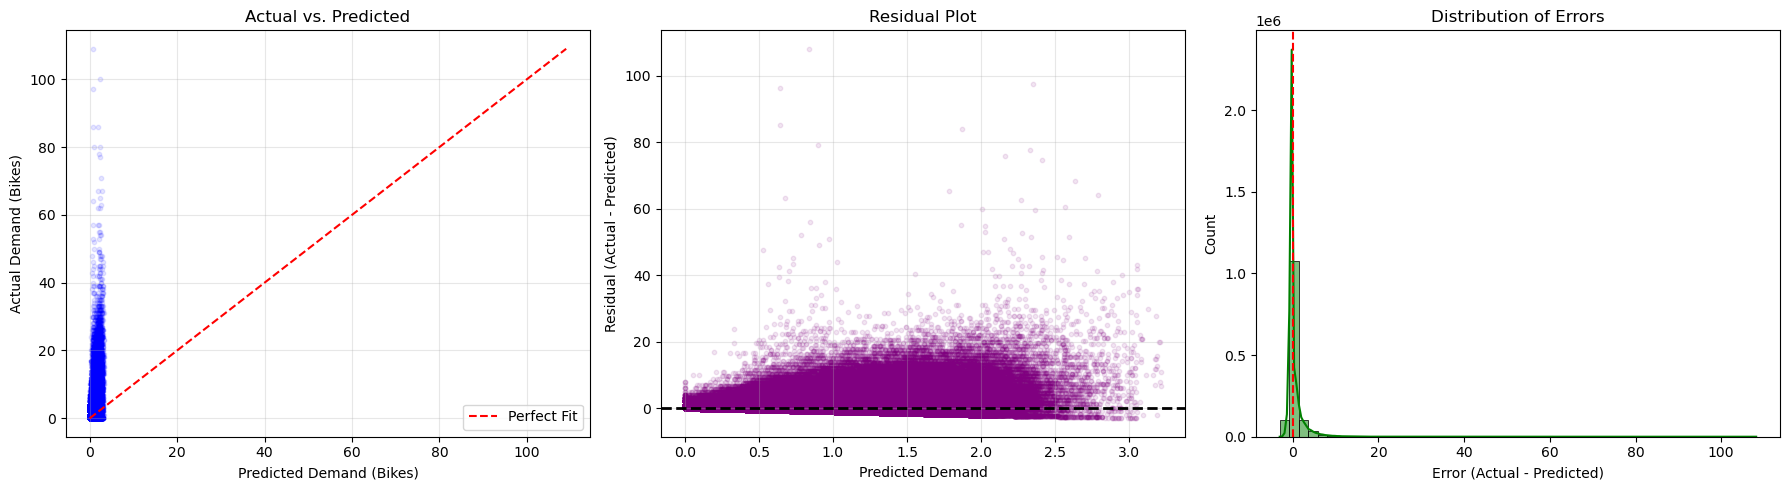

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Setup Data
# We use the variables we calculated in the previous step
actuals = y_test_real
preds = y_pred_test_sample_real
residuals = actuals - preds

# 2. Create Plot
plt.figure(figsize=(18, 5))

# --- Plot A: Actual vs Predicted (The Truth Check) ---
plt.subplot(1, 3, 1)
# We use alpha=0.1 because there are many overlapping dots
plt.scatter(preds, actuals, alpha=0.1, color='blue', s=10)
# Plot the "Perfect Prediction" line (y=x)
max_val = max(actuals.max(), preds.max())
plt.plot([0, max_val], [0, max_val], '--', color='red', label='Perfect Fit')
plt.xlabel('Predicted Demand (Bikes)')
plt.ylabel('Actual Demand (Bikes)')
plt.title('Actual vs. Predicted')
plt.legend()
plt.grid(True, alpha=0.3)

# --- Plot B: Residuals vs Predicted (The Bias Check) ---
plt.subplot(1, 3, 2)
plt.scatter(preds, residuals, alpha=0.1, color='purple', s=10)
plt.axhline(0, color='black', linestyle='--', linewidth=2)
plt.xlabel('Predicted Demand')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot')
plt.grid(True, alpha=0.3)

# --- Plot C: Distribution of Errors (The Normality Check) ---
plt.subplot(1, 3, 3)
sns.histplot(residuals, bins=50, kde=True, color='green')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Error (Actual - Predicted)')
plt.title('Distribution of Errors')

plt.tight_layout()
plt.show()

For the sake of time, I decided not to test Ridge, ElasticNet, or Lasso (on full training set), because based on results for the MLR model, it appears as if a linear regression is too simple a model to capture the complexity of the problem.